Признаков: 17, объектов: 800
Epoch 20/100 - Train Loss: 0.5010, Val Loss: 0.5194
Epoch 40/100 - Train Loss: 0.4185, Val Loss: 0.4406
Epoch 60/100 - Train Loss: 0.3594, Val Loss: 0.3720
Epoch 80/100 - Train Loss: 0.3035, Val Loss: 0.3218
Epoch 100/100 - Train Loss: 0.2715, Val Loss: 0.2764


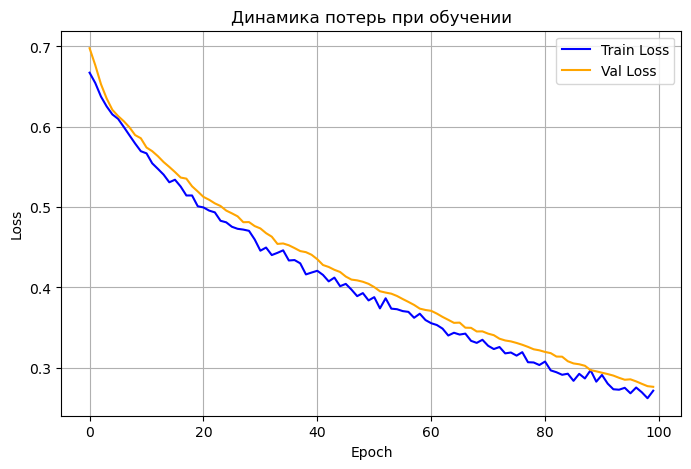


Оценка на валидационной выборке:
Accuracy:  0.9500
Precision: 0.8889
Recall:    0.8276
F1-score:  0.8571
ROC-AUC:   0.9810

Confusion Matrix:
[[128   3]
 [  5  24]]


In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt


TARGET_COL = 'prediction'  
ID_COL = 'patient_id'      

train_df = pd.read_csv('train.csv') 
test_df = pd.read_csv('test_features.csv')


train_df = train_df.fillna(train_df.median(numeric_only=True))
test_df = test_df.fillna(test_df.median(numeric_only=True))
train_df = train_df.replace([np.inf, -np.inf], 0)
test_df = test_df.replace([np.inf, -np.inf], 0)

test_ids = test_df[ID_COL].values

X = train_df.drop(columns=[TARGET_COL, ID_COL]).values.astype(np.float32)
y = train_df[TARGET_COL].values.astype(np.float32).reshape(-1, 1)
X_test = test_df.drop(columns=[ID_COL]).values.astype(np.float32)

print(f"Признаков: {X.shape[1]}, объектов: {X.shape[0]}")


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = RobustScaler() 
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)


X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t), batch_size=batch_size, shuffle=False)


class BreastCancerFFN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64) 
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 1) 
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BreastCancerFFN(X_train_t.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.0001)


epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        has_nan = False
        for param in model.parameters():
            if param.grad is not None and (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()):
                has_nan = True
                break
        if has_nan:
            optimizer.zero_grad()
            continue 
        
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)
    
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика потерь при обучении')
plt.legend()
plt.grid(True)
plt.show()


model.eval()
y_val_pred_prob = []
y_val_true = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        probs = torch.nan_to_num(probs, nan=0.5)
        y_val_pred_prob.extend(probs.cpu().numpy().flatten())
        y_val_true.extend(y_batch.numpy().flatten())

y_val_pred_prob = np.nan_to_num(np.array(y_val_pred_prob), nan=0.5)
y_val_true = np.array(y_val_true)
y_val_pred_class = (y_val_pred_prob >= 0.5).astype(int)

print("\n" + "="*50)
print("Оценка на валидационной выборке:")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_val_true, y_val_pred_class):.4f}")
print(f"Precision: {precision_score(y_val_true, y_val_pred_class, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val_true, y_val_pred_class, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_val_true, y_val_pred_class, zero_division=0):.4f}")

if not np.isnan(y_val_pred_prob).any():
    print(f"ROC-AUC:   {roc_auc_score(y_val_true, y_val_pred_prob):.4f}")
else:
    print("ROC-AUC: не удалось посчитать (NaN)")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_true, y_val_pred_class))


model.eval()
y_test_pred_prob = []
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch[0].to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        probs = torch.nan_to_num(probs, nan=0.5)
        y_test_pred_prob.extend(probs.cpu().numpy().flatten())

y_test_pred_class = (np.array(y_test_pred_prob) >= 0.5).astype(int)


os.makedirs('outputs', exist_ok=True)
submission = pd.DataFrame({
    'patient_id': test_ids,
    'prediction': y_test_pred_class
})
submission.to_csv('outputs/task1_predictions.csv', index=False)